In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

monthly_activity_df = pd.read_csv('../data/synthetic/monthly_activity.csv')

print(monthly_activity_df.shape)
monthly_activity_df.head()
monthly_activity_df.info()
monthly_activity_df.describe(include='all')

#check nulls
null_summary = pd.DataFrame({
    'nulls': monthly_activity_df.isnull().sum(),
    'pct':   (monthly_activity_df.isnull().sum() / len(monthly_activity_df) * 100).round(2)
})
print(null_summary[null_summary['nulls'] > 0])

(121524, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121524 entries, 0 to 121523
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   customer_id        121524 non-null  int64  
 1   month              121524 non-null  int64  
 2   txn_count          121524 non-null  int64  
 3   txn_amount         121524 non-null  float64
 4   login_count        121524 non-null  int64  
 5   support_contacts   121524 non-null  int64  
 6   utilization_ratio  121524 non-null  float64
 7   churn_start_month  19524 non-null   float64
 8   final_decay        19524 non-null   float64
 9   churned_flag       121524 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 9.3 MB
                    nulls    pct
churn_start_month  102000  83.93
final_decay        102000  83.93


In [23]:
# bank_churners_df = pd.read_csv('../data/raw/BankChurners.csv')
# # drop the two naive Bayes columns as per Kaggle dataset instruction
# bank_churners_df.drop(columns=bank_churners_df.columns[-2:], inplace=True)
# bank_churners_df = bank_churners_df.rename(columns={'CLIENTNUM': 'customer_id', 'Attrition_Flag': 'churn_flag'})
# bank_churners_df['churn_flag'] = (bank_churners_df['churn_flag'] == 'Attrited Customer').astype(int)
#
# print(bank_churners_df.shape)
# bank_churners_df.head()
# bank_churners_df.info()
# bank_churners_df.describe(include='all')

(10127, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10127 non-null  int64  
 1   churn_flag                10127 non-null  int64  
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64

,customer_id,churn_flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127,10127.000000,10127,10127,10127,10127,10127.000000,...,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
unique,NaN,NaN,NaN,2,NaN,7,4,6,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,F,NaN,Graduate,Married,Less than $40K,Blue,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,5358,NaN,3128,4687,3561,9436,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.391776e+08,0.160660,46.325960,NaN,2.346203,NaN,NaN,NaN,NaN,35.928409,...,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,0.367235,8.016814,NaN,1.298908,NaN,NaN,NaN,NaN,7.986416,...,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,0.000000,26.000000,NaN,0.000000,NaN,NaN,NaN,NaN,13.000000,...,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,0.000000,41.000000,NaN,1.000000,NaN,NaN,NaN,NaN,31.000000,...,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,0.000000,46.000000,NaN,2.000000,NaN,NaN,NaN,NaN,36.000000,...,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,0.000000,52.000000,NaN,3.000000,NaN,NaN,NaN,NaN,40.000000,...,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000


In [28]:
# consistent style across all charts
plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'figure.dpi':        150,
})

CHURN_COLOR    = '#E05A3A'
RETAIN_COLOR   = '#534AB7'
NEUTRAL_COLOR  = '#3BAA82'


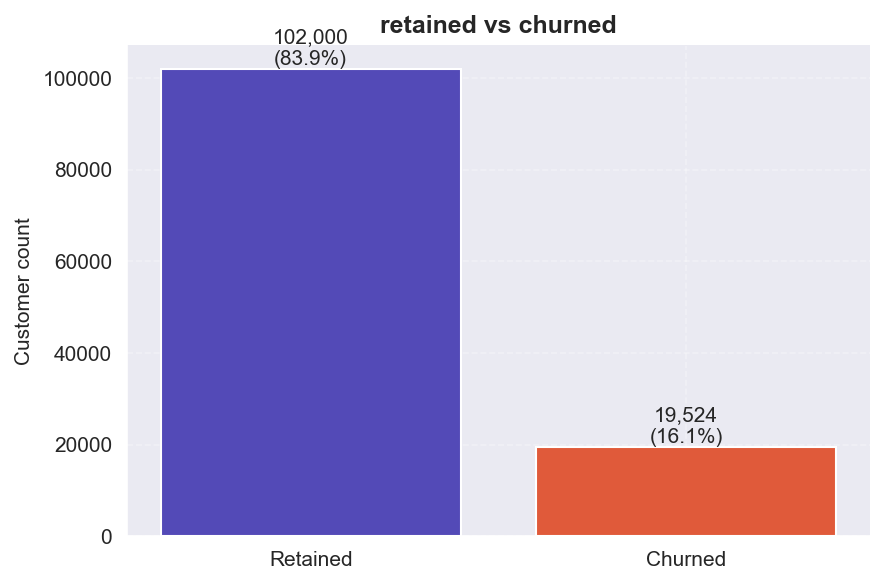

In [32]:
# vis 1 - retained vs churned
churn_counts = monthly_activity_df['churned_flag'].value_counts()
churn_pct    = monthly_activity_df['churned_flag'].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Retained', 'Churned'], churn_counts.values, color=[RETAIN_COLOR, CHURN_COLOR])
ax.bar_label(bars, labels=[f"{v:,}\n({p:.1f}%)" for v, p in zip(churn_counts.values, churn_pct.values)], padding=0)
ax.set_title('retained vs churned', fontweight='bold')
ax.set_ylabel('Customer count')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/processed/eda_class_balance.png', dpi=150)
plt.show()
